In [1]:
'''
This notebook is used to do explore and visualize some of the relationship between anthro features vs positons
NB also models how important anthro features are to performance
'''

'\nThis notebook is used to do explore and visualize some of the relationship between anthro features vs positons\nNB also models how important anthro features are to performance\n'

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import os
# import seaborn as sns
from scipy import stats
# import seaborn as sns

from sklearn.preprocessing import MinMaxScaler # normalize graphs --> easier to viz.

In [3]:
# Paths

try:
    main_directory = Path(__file__).parent
except NameError:
    main_directory = Path(os.path.dirname(os.getcwd()))  # fallback for Jupyter

data_folder = main_directory / 'data' # data folder output
notebook_folder = main_directory / 'notebooks' 
results_folder = main_directory / 'results'

In [4]:
# Just put it here for now
scaler = MinMaxScaler()

In [5]:
# Model data


df_def = pd.read_csv(data_folder / 'def_model_data.csv')
df_qb = pd.read_csv(data_folder / 'qb_model_data.csv')
df_wr = pd.read_csv(data_folder / 'wr_model_data.csv')
df_rb = pd.read_csv(data_folder/ 'rb_model_data.csv')
df_roster = pd.read_csv(data_folder/'roster_model_data.csv')

In [6]:
for col in df_rb.columns:
    print(col)

rusher_player_id
season
rushing_epa
rush_attempts
epa_per_rush
epa_per_rush_prior
rookie_flag
years_experience
draft_round
draft_pick
weight_lbs
height_in
arm_length_in
wing_span_in
hand_size_in
yard_40_dash_sec
yard_60_shuttle_sec
yard_10_split_sec
yard_20_split_sec
cone_drill_sec
yard_20_shuttle_sec
vert_jump_in
broad_jump_in
bench_press_reps
gsis_id
position_group
missing_weight_lbs
missing_height_in
missing_arm_length_in
missing_wing_span_in
missing_hand_size_in
missing_yard_40_dash_sec
missing_yard_60_shuttle_sec
missing_yard_10_split_sec
missing_yard_20_split_sec
missing_cone_drill_sec
missing_yard_20_shuttle_sec
missing_vert_jump_in
missing_broad_jump_in
missing_bench_press_reps


In [7]:
# combine all and keep anthro data + positions - for comparisons

df_all_pos = pd.concat([df_def, df_qb, df_wr, df_rb], ignore_index=True)

df_all_pos['position_source'] = np.select(
    [
        df_all_pos['passer_player_id'].notna(),
        df_all_pos['rusher_player_id'].notna(),
        df_all_pos['receiver_player_id'].notna(),
        df_all_pos['defender_id'].notna()
    ],
    ['qb', 'rb', 'wr', 'def'],
    default='unknown'
) # get source of row data

df_all_pos['bmi'] = (df_all_pos['weight_lbs']/df_all_pos['height_in']**2) * 703 # Get bmi

# df_all_pos['id'] = df_all_pos['defender_id'].fillna(df_all_pos['passer_player_id']).fillna(df_all_pos['receiver_player_id']).fillna(df_all_pos['rusher_player_id']) # get single player_id col
# Just anthro features + season
# df_all_pos_anthro = df_all_pos[['id', 'season', 'position_group', 'md_weight_lbs', 'md_height_in']] # Just anthro features + season
# df_all_pos_anthro['bmi'] = df_all_pos_anthro['weight (lbs)']/df_all_pos_anthro['height (in)']**2
# # anthro features + epa + season
# df_all_pos_ = df_all_pos[['season', 'position_group', 'md_weight_lbs', 'md_height_in']] # Just anthro features + season

In [8]:
# Number of rows per position
print(df_all_pos['position_source'].value_counts())

position_source
wr     2949
def    2203
rb     1464
qb     1109
Name: count, dtype: int64


In [9]:
# Number of unique players in each positioon

df_count =  df_all_pos.drop_duplicates(subset=['gsis_id','position_source'])
print(df_count['position_source'].value_counts())

position_source
wr     676
def    516
rb     359
qb     205
Name: count, dtype: int64


## EDA

In [10]:

measurement_list = ['weight_lbs', 'height_in', 'bmi', 'arm_length_in','wing_span_in','hand_size_in'] 
pos_order = ['lb', 'db', 'dl', 'qb', 'wr', 'te', 'rb'] # Order for graphs
position_config = {
    'qb':  {'df': df_all_pos[df_all_pos['position_source'] == 'qb'],  'player_id': 'passer_player_id',  'target': 'epa_per_dropback'},
    'rb':  {'df': df_all_pos[df_all_pos['position_source'] == 'rb'],  'player_id': 'rusher_player_id',  'target': 'epa_per_rush'},
    'wr':  {'df': df_all_pos[df_all_pos['position_source'] == 'wr'],  'player_id': 'receiver_player_id','target': 'epa_per_target'},
    'def': {'df': df_all_pos[df_all_pos['position_source'] == 'def'], 'player_id': 'defender_id',       'target': 'def_epa_per_play'},
} # position to target relevant info

df_graph = df_all_pos.drop_duplicates(subset=['gsis_id']).copy() # Unique values for height vs weight comparisons

In [11]:
df_graph.to_csv('test.csv')

## Height and Weight by Position

NameError: name 'sns' is not defined

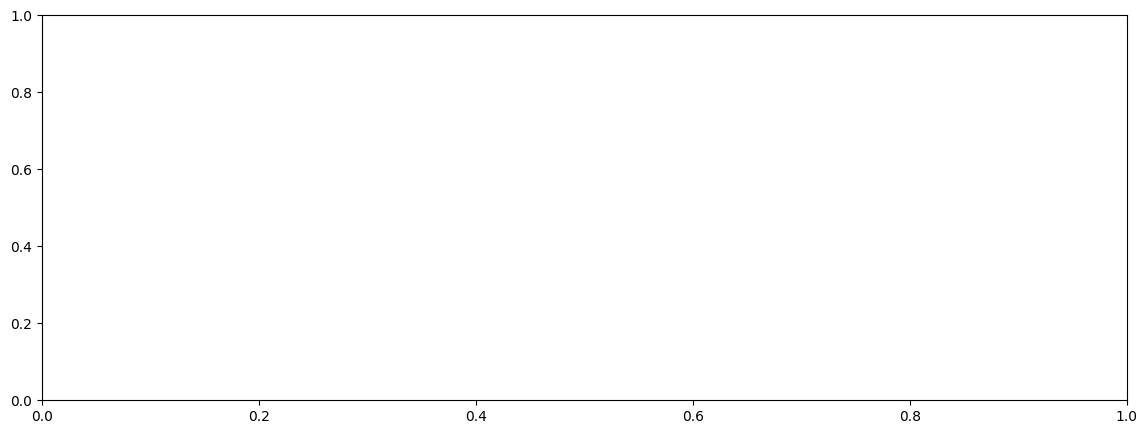

In [12]:
for measurement in measurement_list:
    total_obs = df_graph[measurement].notna().sum()
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.stripplot(x='position_group', y=measurement, data=df_graph, order=pos_order, ax=ax)
    ax.set_title(f'{measurement.capitalize()} by Position (n={total_obs})')
    ax.set_xlabel('Position')
    ax.set_ylabel(measurement)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(results_folder/f'{measurement.lower()}_by_position.png')
    plt.show()

## Outlier detection by Group

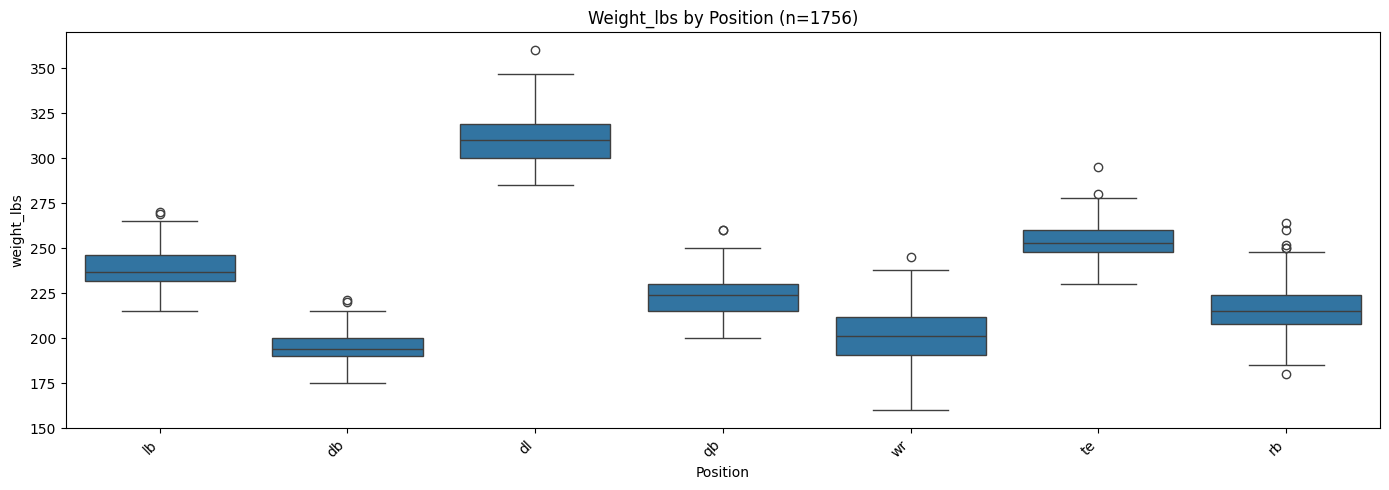

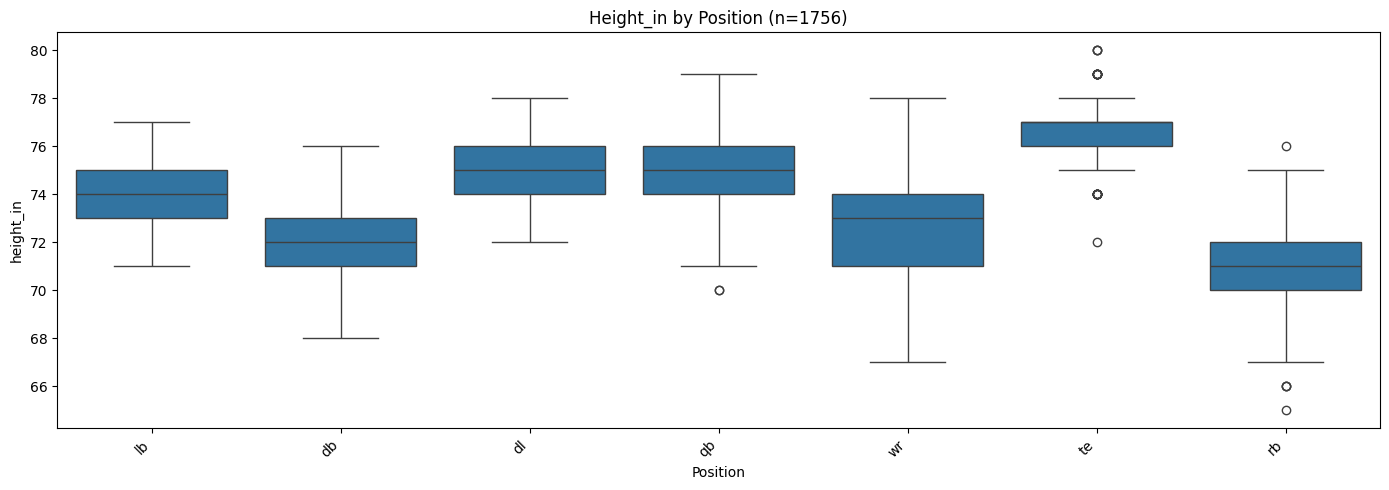

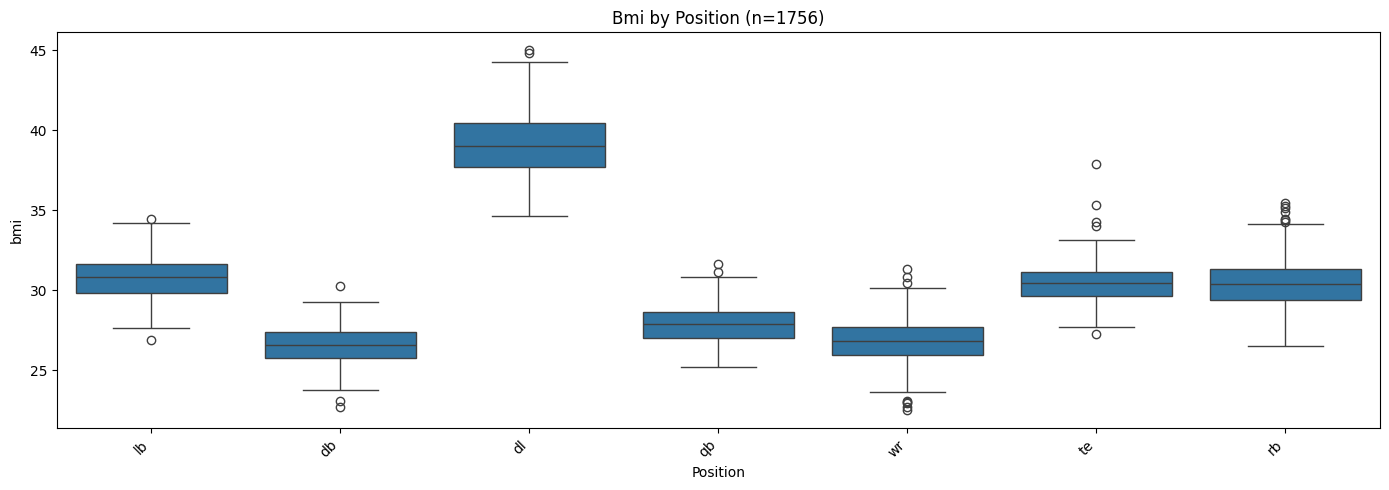

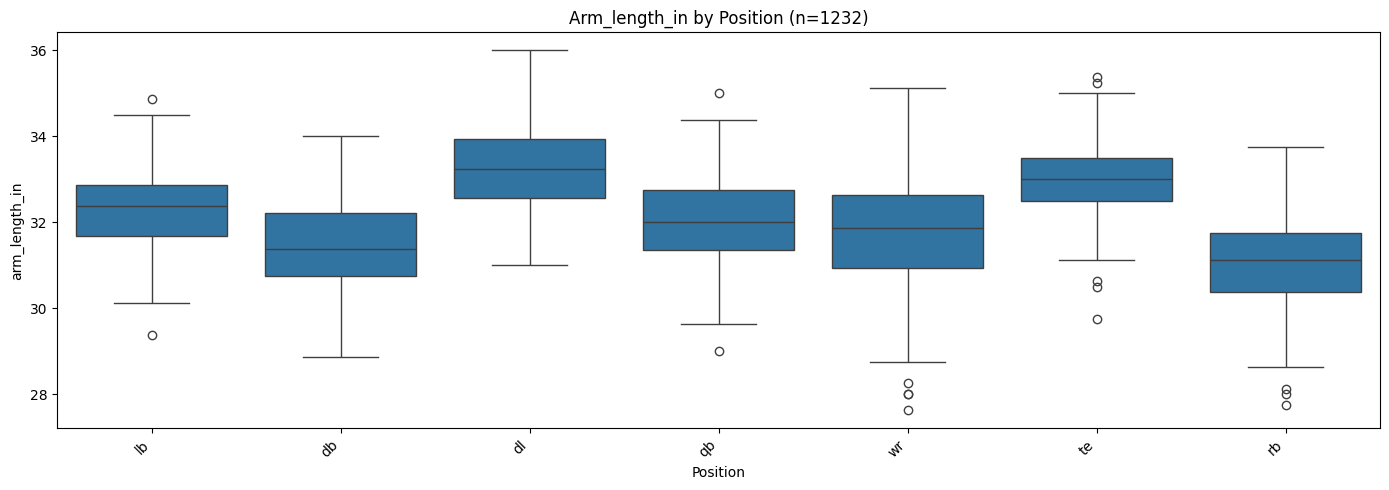

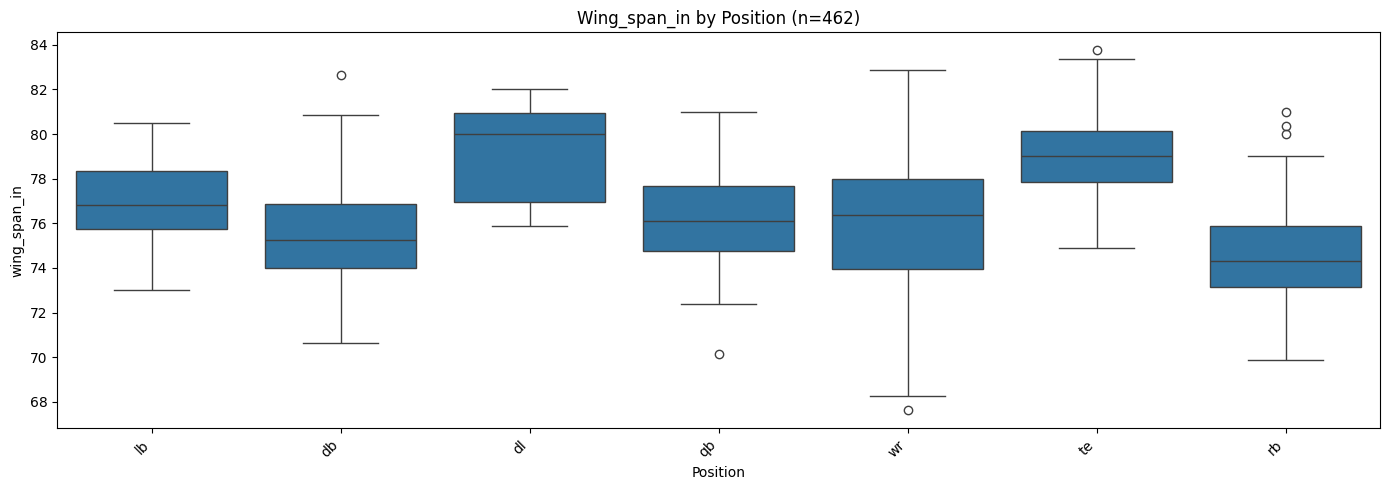

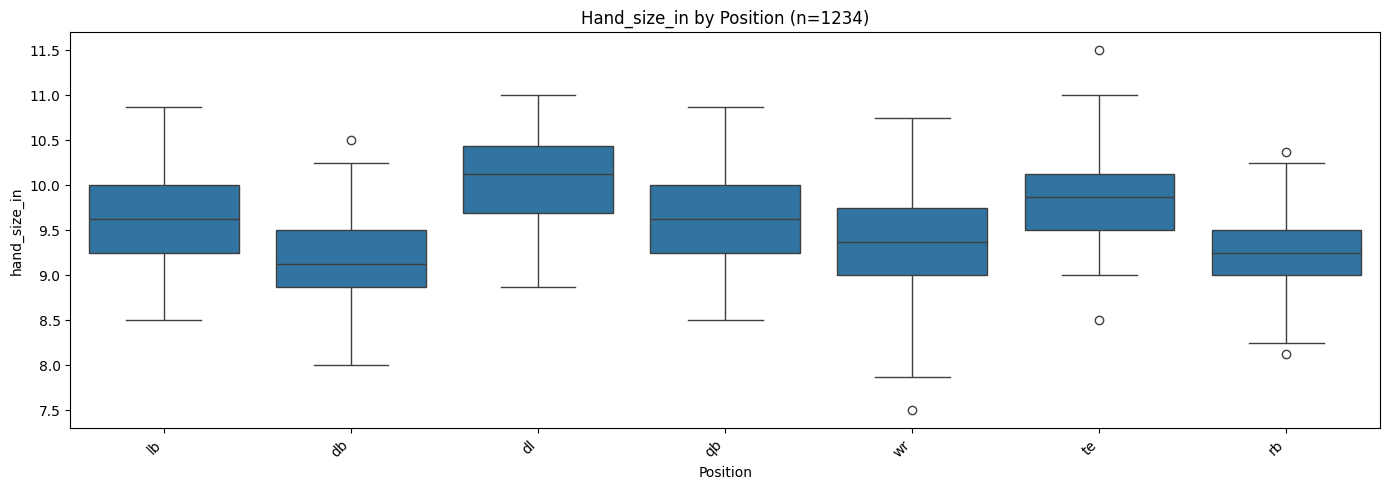

In [ ]:
for measurement in measurement_list: 
    total_obs = df_graph[measurement].notna().sum()
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(x='position_group', y=measurement, data=df_graph, order=pos_order, ax=ax)
    ax.set_title(f'{measurement.capitalize()} by Position (n={total_obs})')
    ax.set_xlabel('Position')
    ax.set_ylabel(measurement)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(results_folder/f'boxplots_{measurement.lower()}_by_position.png')
    plt.show()



In [ ]:
def count_outliers(x):
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    return ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum()

for measurement in measurement_list: 

    
    if measurement == 'bmi':
        outlier_counts = df_graph.groupby('position_group')[measurement].apply(count_outliers)
        total_obs = df_graph[measurement].count()
    else:
        outlier_counts = df_graph[df_graph[f'missing_{measurement}'] != 1].groupby('position_group')[measurement].apply(count_outliers)
        total_obs = df_graph[measurement][df_graph[f'missing_{measurement}'] != 1][df_graph[f'missing_{measurement}'] != 1].count()
        
    outlier_counts = df_graph.groupby('position_group')[measurement].apply(count_outliers)
    total_counts = df_graph.groupby('position_group')[measurement].count()
    
    summary = pd.DataFrame({
        'outlier_count': outlier_counts,
        'total_count': total_counts,
        'outlier_pct': (outlier_counts / total_counts * 100).round(1)
    }).sort_values('outlier_pct', ascending=False)
    
    print(f"\n{measurement.capitalize()}:\n", summary.to_string())


Weight_lbs:
                 outlier_count  total_count  outlier_pct
position_group                                         
rb                          6          359          1.7
lb                          2          144          1.4
dl                          1          103          1.0
te                          2          204          1.0
qb                          2          205          1.0
db                          2          269          0.7
wr                          1          472          0.2

Height_in:
                 outlier_count  total_count  outlier_pct
position_group                                         
te                         23          204         11.3
rb                          5          359          1.4
qb                          2          205          1.0
lb                          0          144          0.0
dl                          0          103          0.0
db                          0          269          0.0
wr                   

In [ ]:
summary.to_csv(results_folder/'outlier_table.csv', index=False)

## Trend Analysis over Seasons

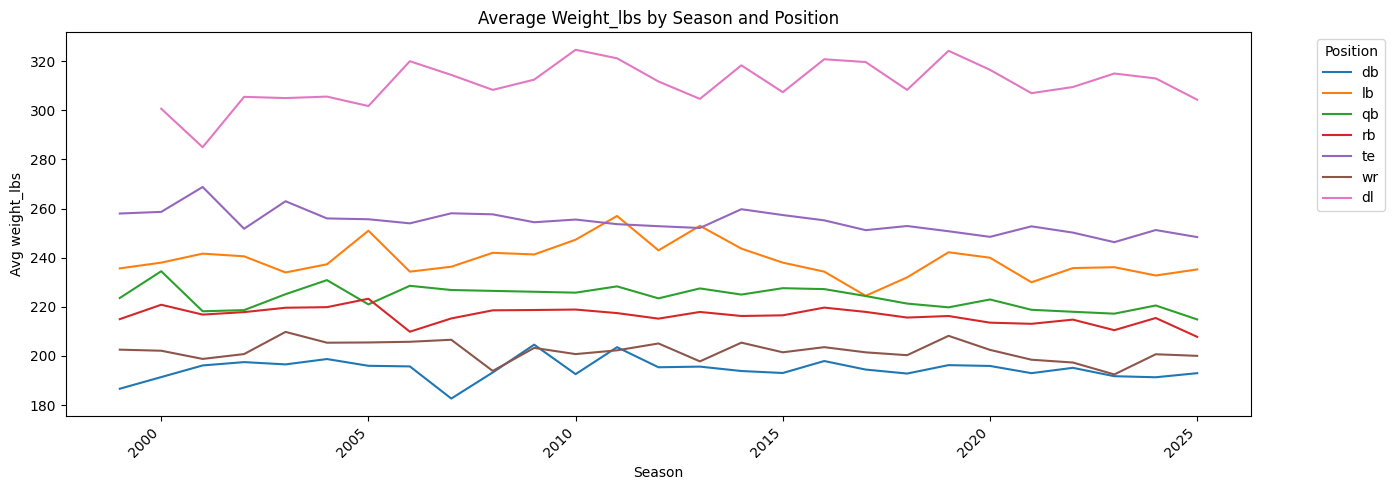

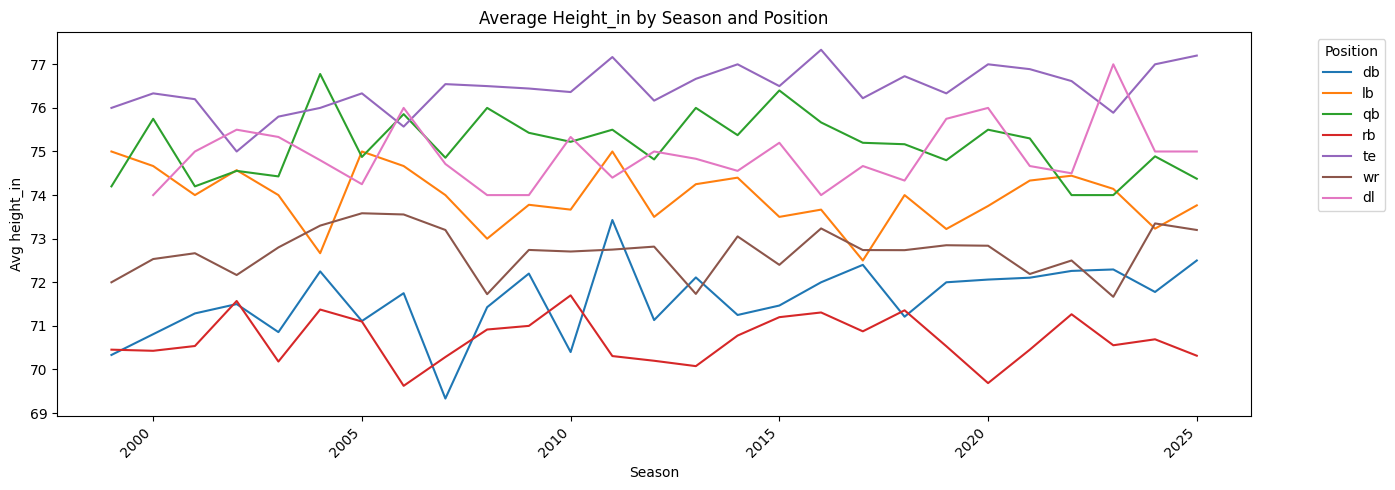

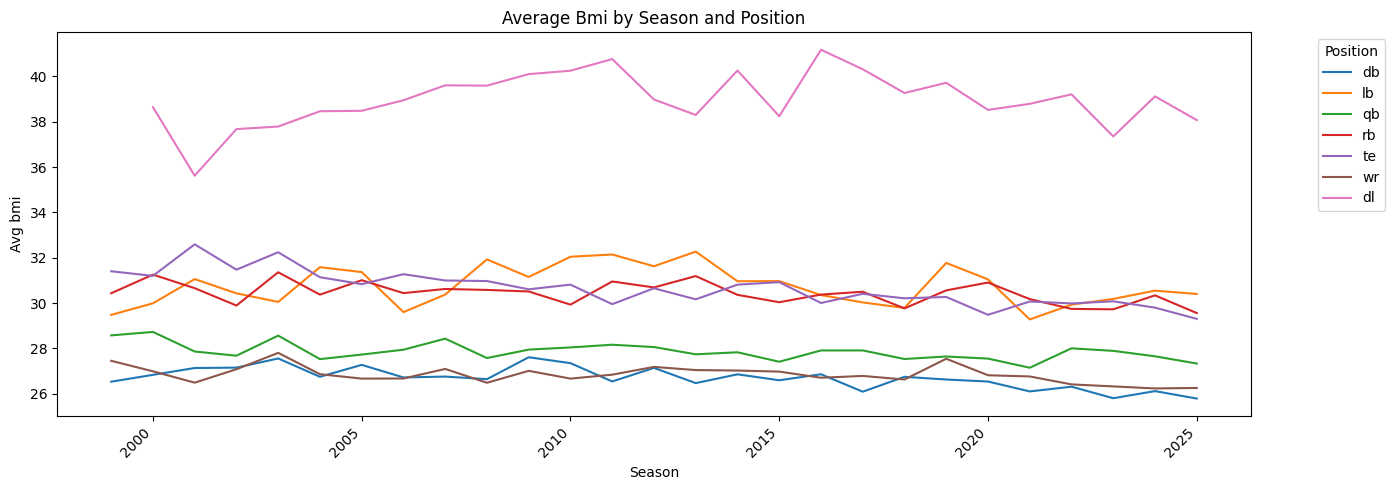

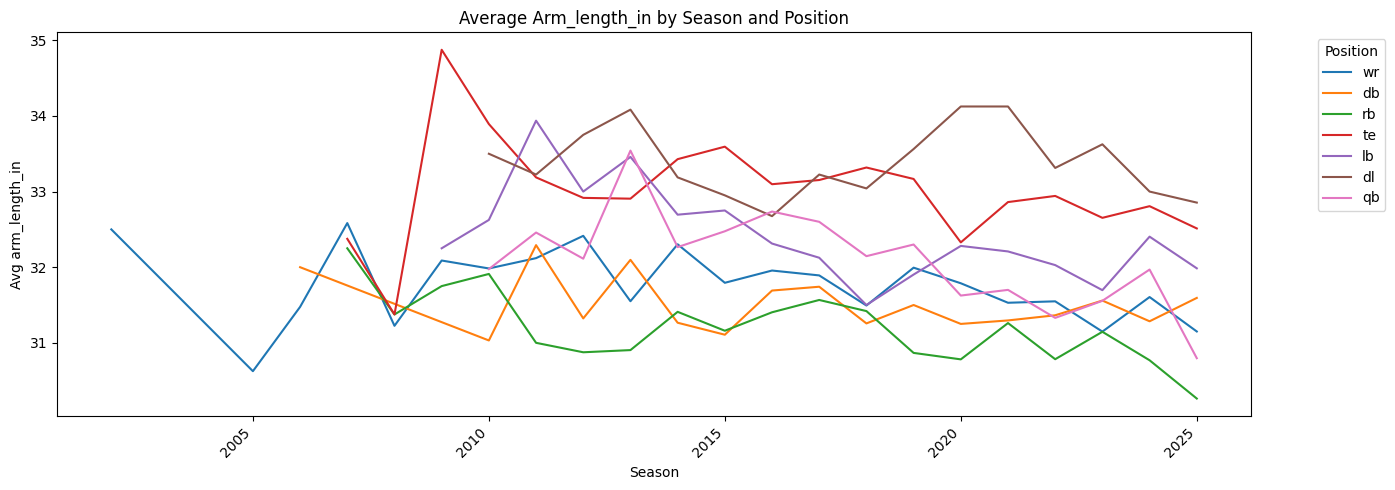

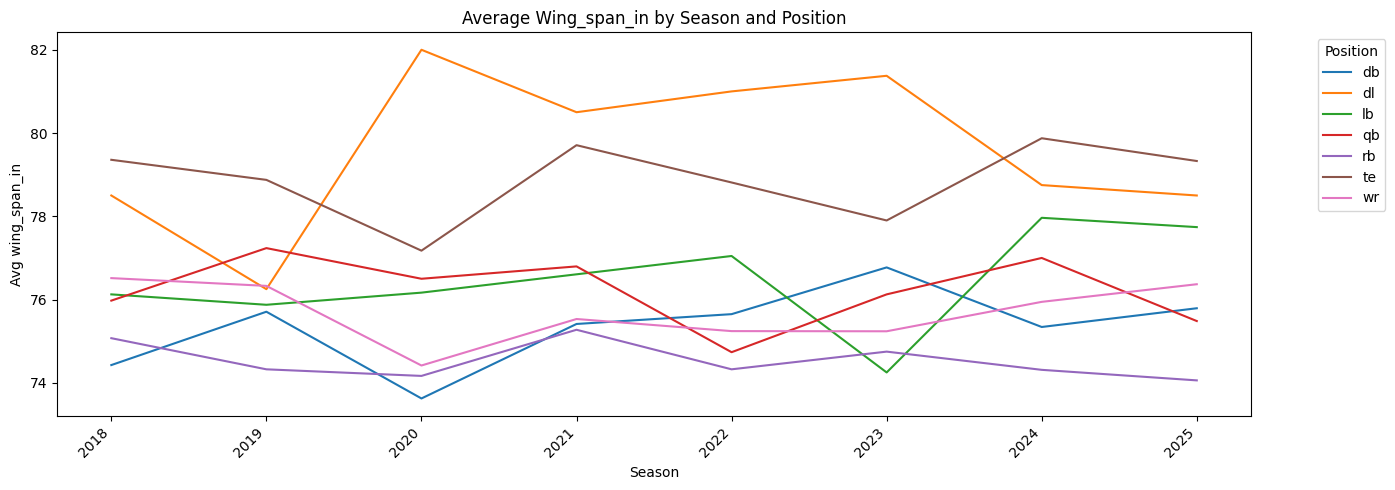

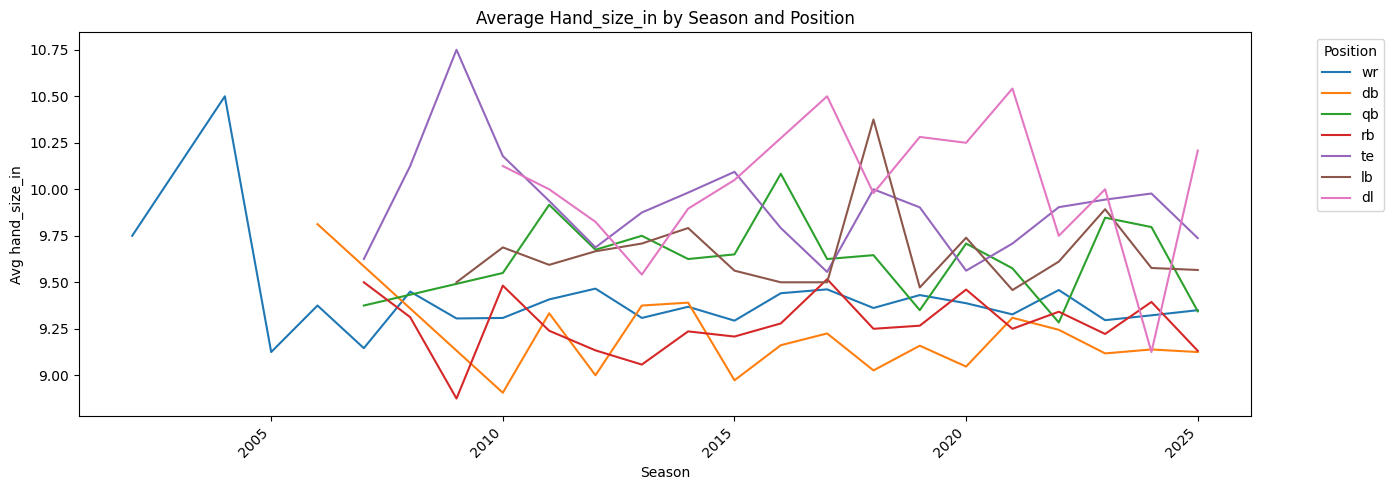

In [ ]:
for measurement in measurement_list:
    df_sns = df_graph[df_graph[measurement].notna()].copy()
    df_sns = df_sns.drop_duplicates(subset=['gsis_id', 'season'])
    
    season_avg = df_sns.groupby(['season', 'position_group'])[measurement].mean().reset_index()
    
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.lineplot(x='season', y=measurement, hue='position_group', data=season_avg, ax=ax)
    ax.set_title(f'Average {measurement.capitalize()} by Season and Position')
    ax.set_xlabel('Season')
    ax.set_ylabel(f'Avg {measurement}')
    # ax.set_ylim(bottom=0)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(results_folder/f'avg_{measurement.lower()}_season_pos.png')
    plt.show()

## Correlation - Roster

In [ ]:
df_roster.head()

,team,season,team_avg_height,team_avg_weight,pass_epa,dropbacks,rush_epa,rush_attempts,total_off_plays,off_epa_per_play,...,dropbacks_faced,rush_epa_allowed,rush_attempts_faced,total_def_plays,def_epa_per_play,team_qb_epa,off_epa_prior,def_epa_prior,first_season_flag,net_epa_per_play
0,ARI,1999,74.671875,254.859375,-117.134066,604.0,-72.284747,396.0,1000.0,-0.189419,...,532.0,-5.724189,542.0,1074.0,-0.012730,NaN,NaN,NaN,1,-0.176689
1,ARI,2000,74.323944,251.197183,-69.705888,597.0,-70.759920,346.0,943.0,-0.148956,...,487.0,32.539719,579.0,1066.0,0.111125,NaN,-0.189419,-0.012730,0,-0.260082
2,ARI,2001,74.153846,247.046154,31.898784,571.0,-63.029843,401.0,972.0,-0.032028,...,591.0,-22.647174,497.0,1088.0,0.024941,NaN,-0.148956,0.111125,0,-0.056969
3,ARI,2016,74.245098,243.166667,9.804531,692.0,-33.140294,399.0,1091.0,-0.021389,...,621.0,-63.719302,424.0,1045.0,-0.093461,0.010240,0.101693,-0.095615,0,0.072072
4,ARI,2017,74.173077,239.846154,-92.926690,667.0,-81.773024,409.0,1076.0,-0.162360,...,623.0,-63.937718,409.0,1032.0,-0.102575,-0.143737,-0.021389,-0.093461,0,-0.059786


In [13]:

measurement_list_team = ['team_avg_height', 'team_avg_weight'] 

targets_team = ['net_epa_per_play', 'off_epa_per_play', 'def_epa_per_play'] 

df_team_graph = df_roster.copy()


NameError: name 'sns' is not defined

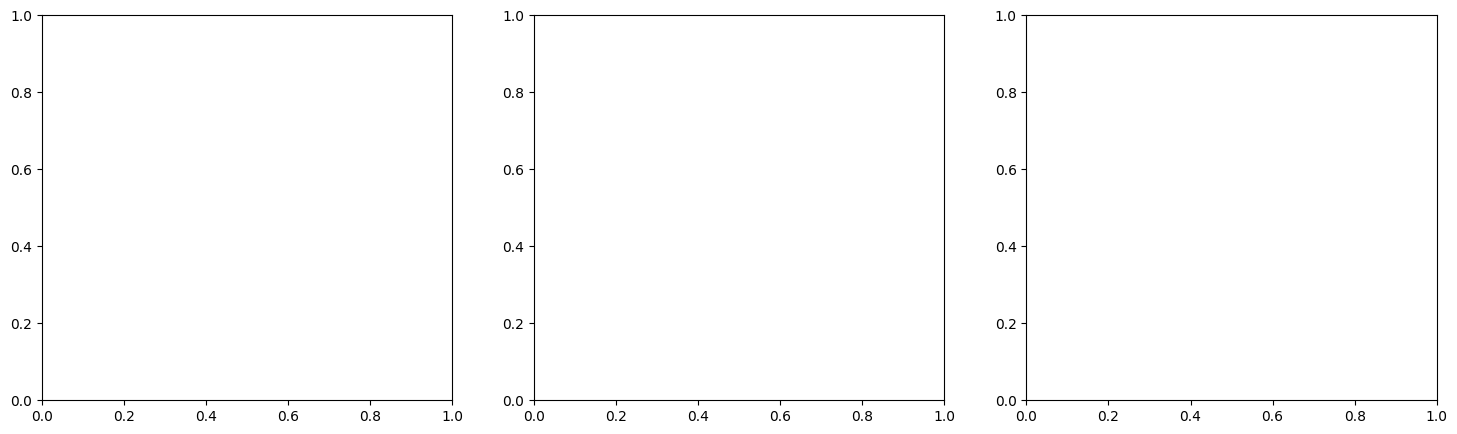

In [14]:


for measurement in measurement_list_team:
    
    fig, axes = plt.subplots(1, len(targets_team), figsize=(18, 5))
    
    for i, target in enumerate(targets_team):
        ax = axes[i]
        
        # Drop NaNs per pair
        df_plot = df_team_graph[[measurement, target]].dropna()
        
        # Scatter + trend line
        sns.regplot(
            data=df_plot,
            x=measurement,
            y=target,
            ax=ax,
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'}
        )
        
        corr = df_plot[measurement].corr(df_plot[target])
        
        ax.set_title(f"{target}\nCorr = {corr:.3f}")
        ax.set_xlabel(measurement)
        ax.set_ylabel(target)
    
    plt.suptitle(f"{measurement} vs Team Performance Metrics", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{results_folder}/team_{measurement}_performance.png")
    plt.show()

In [15]:
print(len(measurement_list))

6


In [16]:
# corr_results = {}
# for model in position_config:
#     corr_results_pos = {}
#     position = model
#     target = position_config[model]['target']

#     df_corr = df_graph.copy()
#     df_corr = df_corr[df_corr['position_source'] == model]
#     for measurement in measurement_list:
#         corr_measurements = df_corr[measurement].corr(df_corr[target])
#         corr_results_pos[measurement] = corr_measurements 

#     corr_results[position] = corr_results_pos


In [17]:
# display(corr_results)

# Models

In [56]:
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score


## Anthro features for players

In [19]:
df_def = pd.read_csv(data_folder / 'def_model_data.csv')
df_qb = pd.read_csv(data_folder / 'qb_model_data.csv')
df_wr = pd.read_csv(data_folder / 'wr_model_data.csv')
df_rb = pd.read_csv(data_folder/ 'rb_model_data.csv')

In [20]:
model_config = {
    'qb':  {'df': df_qb,  'player_id': 'passer_player_id',  'target': 'qb_epa_per_dropback', 'drop_cols' : ['passing_epa', 'qb_epa', 'dropbacks', 'epa_per_dropback']},
    'rb':  {'df': df_rb,  'player_id': 'rusher_player_id',  'target': 'epa_per_rush', 'drop_cols': ['rushing_epa', 'rush_attempts']},
    'wr':  {'df': df_wr,  'player_id': 'receiver_player_id','target': 'epa_per_target', 'drop_cols': ['receiving_epa', 'targets']},
    'def': {'df': df_def, 'player_id': 'defender_id',       'target': 'def_epa_per_play', 'drop_cols': ['total_def_epa', 'plays']} 
}

# Drop_cols are leaky columns

In [ ]:
# baseline_features = [
#     "epa_per_play_prior",     # or position-specific prior (e.g. epa_per_dropback_prior)
#     "usage_metric",           # varies by position
# ]

# anthro_features = [
#     "height_in",
#     "weight_lbs",
#     "hand_size_in",
#     "arm_length_in",
#     "forty_time",
#     "vert_jump_in",
#     "broad_jump_in",
#     "cone_drill_sec",
#     "bench_press_reps",
# ]

In [22]:
baseline_features = [
    'season', 
    'total_def_epa', 
    'plays', 
    'def_epa_per_play_prior', 
    'rookie_flag', 
    'years_experience', 
    'draft_round', 
    'draft_pick', 
    'passing_epa', 
    'qb_epa', 
    'dropbacks', 
    'epa_per_dropback', 
    'epa_per_dropback_prior', 
    'qb_epa_per_dropback_prior', 
    'targets', 
    'epa_per_target_prior', 
    'rushing_epa', 
    'rush_attempts', 
    'epa_per_rush_prior'    # varies by position
]

anthro_features = ['weight_lbs', 
                   'height_in', 
                   'arm_length_in', 
                   'wing_span_in', 
                   'hand_size_in', 
                   'yard_40_dash_sec', 
                   'yard_60_shuttle_sec', 
                   'yard_10_split_sec', 
                   'yard_20_split_sec', 
                   'cone_drill_sec', 
                   'yard_20_shuttle_sec', 
                   'vert_jump_in', 
                   'broad_jump_in', 
                   'bench_press_reps', 
                   'missing_weight_lbs', 
                   'missing_height_in', 
                   'missing_arm_length_in', 
                   'missing_wing_span_in', 
                   'missing_hand_size_in', 
                   'missing_yard_40_dash_sec', 
                   'missing_yard_60_shuttle_sec', 
                   'missing_yard_10_split_sec', 
                   'missing_yard_20_split_sec', 
                   'missing_cone_drill_sec', 
                   'missing_yard_20_shuttle_sec', 
                   'missing_vert_jump_in', 
                   'missing_broad_jump_in',
                   'missing_bench_press_reps'
]

In [41]:
def ridge_cv_model(df, target, baseline_features, anthro_features, position_name):
    print(f"{'-'*10}{position_name.upper()}{'-'*10}")
    df = df.copy().dropna(subset=[target])

    model_results = {}
    feature_sets = {
        'baseline': baseline_features,
        'baseline+anthro': baseline_features + anthro_features
    }

    for feature_label, feature in feature_sets.items():
        y = df[target]
        available_cols = [col for col in df.columns if col in feature and col != target]
        X = df[available_cols]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)


        X_train = X_train.dropna(axis=1, how='all') # drop irrelevant columns
        X_test = X_test[X_train.columns]  

        alphas_ = np.logspace(-4, 4, 100) # exploratory, can change if needed
        
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("ridge", RidgeCV(alphas=alphas_))
        ])
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        r2 = r2_score(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)

        print(f'  [{feature_label}] R2: {r2:.4f} | RMSE: {rmse:.4f}')

        coef_df = pd.DataFrame({
            'feature': X_train.columns.tolist(),
            'coefficient': model.named_steps['ridge'].coef_
        }).sort_values(by='coefficient', key=abs, ascending=False)

        print(f'  Feature Importance:\n{coef_df}\n')

        model_results[feature_label] = {
            'RMSE': rmse,
            'R2': r2,
            'feature_imp': coef_df
        }

    return model_results

In [42]:
results  = {}

In [43]:
for position, pos_dict in model_config.items():
    # print(pos_dict['player_id']) 
    position_data = pos_dict['df'].select_dtypes(include=[np.number])
    position_data = position_data.drop(columns=pos_dict['drop_cols'])
    position_target = pos_dict['target']
    results[position] = ridge_cv_model(position_data, position_target, baseline_features, anthro_features, position)

----------QB----------
  [baseline] R2: 0.1139 | RMSE: 0.2180
  Feature Importance:
                     feature  coefficient
2                rookie_flag    -0.034830
4           years_experience     0.033436
3  qb_epa_per_dropback_prior     0.025997
5                draft_round    -0.018103
1     epa_per_dropback_prior     0.016096
6                 draft_pick    -0.013098
0                     season     0.006007

  [baseline+anthro] R2: 0.1400 | RMSE: 0.2148
  Feature Importance:
                        feature  coefficient
2                   rookie_flag    -0.034566
4              years_experience     0.032809
29       missing_cone_drill_sec    -0.024684
3     qb_epa_per_dropback_prior     0.021488
5                   draft_round    -0.015839
1        epa_per_dropback_prior     0.015567
32        missing_broad_jump_in     0.014152
6                    draft_pick    -0.012137
13            yard_10_split_sec    -0.010838
28    missing_yard_20_split_sec     0.010026
27    missing_ya

In [44]:
# Summary metrics — one row per position per feature set
summary_rows = []
for pos, feature_sets in results.items():
    for feature_label, metrics in feature_sets.items():
        summary_rows.append({
            'position': pos,
            'feature_set': feature_label,
            'R2': metrics['R2'],
            'RMSE': metrics['RMSE'],
            'n_features': len(metrics['feature_imp'])
        })

summary_df = pd.DataFrame(summary_rows).sort_values(['position', 'feature_set'])

# Feature importance — one row per feature per position per feature set
importance_df = pd.concat([
    metrics['feature_imp'].assign(position=pos, feature_set=feature_label)
    for pos, feature_sets in results.items()
    for feature_label, metrics in feature_sets.items()
], ignore_index=True)

importance_df['abs_coef'] = importance_df['coefficient'].abs()
importance_df = importance_df.sort_values(
    by=['position', 'feature_set', 'abs_coef'],
    ascending=[True, True, False]
).drop(columns='abs_coef')

print(summary_df)
print(importance_df.head(20))

  position      feature_set        R2      RMSE  n_features
6      def         baseline  0.399549  0.311590           6
7      def  baseline+anthro  0.598693  0.254732          34
0       qb         baseline  0.113947  0.217988           7
1       qb  baseline+anthro  0.139967  0.214763          34
2       rb         baseline -0.012470  0.112089           6
3       rb  baseline+anthro  0.012547  0.110696          34
4       wr         baseline  0.215168  0.367837           6
5       wr  baseline+anthro  0.237787  0.362498          34
                         feature  coefficient position      feature_set
121       def_epa_per_play_prior     0.247879      def         baseline
122                  rookie_flag    -0.049426      def         baseline
123                       season    -0.026615      def         baseline
124                   draft_pick    -0.021019      def         baseline
125                  draft_round     0.005783      def         baseline
126             years_experi

In [45]:
display(summary_df)

,position,feature_set,R2,RMSE,n_features
6,def,baseline,0.399549,0.311590,6
7,def,baseline+anthro,0.598693,0.254732,34
0,qb,baseline,0.113947,0.217988,7
1,qb,baseline+anthro,0.139967,0.214763,34
2,rb,baseline,-0.012470,0.112089,6
3,rb,baseline+anthro,0.012547,0.110696,34
4,wr,baseline,0.215168,0.367837,6
5,wr,baseline+anthro,0.237787,0.362498,34


In [46]:
display(importance_df.head())

,feature,coefficient,position,feature_set
121,def_epa_per_play_prior,0.247879,def,baseline
122,rookie_flag,-0.049426,def,baseline
123,season,-0.026615,def,baseline
124,draft_pick,-0.021019,def,baseline
125,draft_round,0.005783,def,baseline


In [50]:
summary_df.to_csv(results_folder/ "model_summary.csv", index=False)
importance_df.to_csv(results_folder / "feature_importance.csv", index=False)

PermissionError: [Errno 13] Permission denied: 'g:\\My Drive\\Studying\\OMSA Georgia Tech\\Classes\\CSE 6242\\Project\\Research\\model_data\\model_data\\results\\model_summary.csv'

## Anthro features for teams

In [57]:
df_team = df_roster.copy()

team_features = measurement_list_team
team_targets = targets_team # already defined above, just bringing it down
# target

In [58]:
team_results = {}


In [ ]:
team_results = {}
for target in targets_team:
    df_team_model = df_roster[team_features + [target]].dropna()
    
    X = df_team_model[team_features]
    y = df_team_model[target]
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=np.logspace(-4, 4, 50), cv=5))
    ])
    

    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_rmse = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')

    model.fit(X, y)
    ridge = model.named_steps['ridge']
    
    coef_df = pd.DataFrame({
        'feature': team_features,
        'coefficient': ridge.coef_
    }).sort_values(by='coefficient', key=abs, ascending=False)
    
    team_results[target] = {
        'R2_mean': cv_r2.mean(),
        'RMSE_mean': (-cv_rmse).mean(),
        'coefficients': coef_df
    }

    print(f"\n--- {target} ---")
    print(f"CV R2:   {cv_r2.mean():.4f}")
    print(f"CV RMSE: {(-cv_rmse).mean():.4f}")
    
    print(f"\n--- {target} ---")
    print(f"CV R2:   {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")
    print(f"CV RMSE: {(-cv_rmse).mean():.4f} +/- {(-cv_rmse).std():.4f}")
    print(coef_df)


--- net_epa_per_play ---
CV R2:   -0.0288
CV RMSE: 0.1114

--- net_epa_per_play ---
CV R2:   -0.0288 +/- 0.0269
CV RMSE: 0.1114 +/- 0.0038
           feature  coefficient
0  team_avg_height    -0.002131
1  team_avg_weight    -0.000805

--- off_epa_per_play ---
CV R2:   -0.0306
CV RMSE: 0.0899

--- off_epa_per_play ---
CV R2:   -0.0306 +/- 0.0277
CV RMSE: 0.0899 +/- 0.0060
           feature  coefficient
1  team_avg_weight    -0.000290
0  team_avg_height    -0.000211

--- def_epa_per_play ---
CV R2:   -0.0163
CV RMSE: 0.0711

--- def_epa_per_play ---
CV R2:   -0.0163 +/- 0.0211
CV RMSE: 0.0711 +/- 0.0021
           feature  coefficient
0  team_avg_height     0.007409
1  team_avg_weight    -0.001447


In [65]:
rows = []

for target, result in team_results.items():
    r2_mean = result['R2_mean']
    rmse_mean = result['RMSE_mean']
    coef_df = result['coefficients']
    
    for _, row in coef_df.iterrows():
        rows.append({
            'target': target,
            'feature': row['feature'],
            'coefficient': row['coefficient'],
            'R2_mean': r2_mean,
            'RMSE_mean': rmse_mean
        })

team_results_df = pd.DataFrame(rows)

In [66]:
team_results_df.to_csv(results_folder / "team_model_results.csv", index=False)